# Nonlinear equations notebook

## Convergence

After 12 iterations, the function converges to 1.841406 (x = 0.0).
After 12 iterations, the function converges to 1.841406 (x = 1.0).
After 12 iterations, the function converges to 1.841406 (x = 2.0).
After 12 iterations, the function converges to 1.841406 (x = 3.0).
After 12 iterations, the function converges to 1.841406 (x = 4.0).


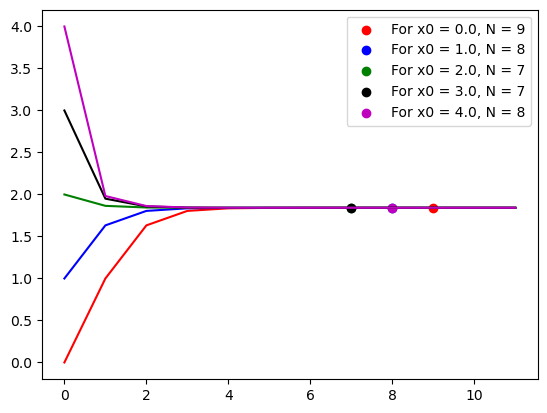

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 

N = 12
accuracy = 1e-5
x_start = np.array([0, 1, 2, 3, 4], dtype='float')

def f(x):
    return 2.0-np.exp(-x)

def relaxation(f, N, x):
    x_array = np.array([x])
    for i in range(1,N):
        x = f(x)
        x_array = np.append(x_array,x)
    return x_array

def find_threshold(array, accurary):
    prev = array[0]
    index = array.size
    flag = 1
    for i in range(1,array.size):
        if np.abs(array[i]-array[i-1]) < accuracy and flag == 1:
            index = i
            flag = 0
    return index

index_array = np.arange(0,N)
fig = plt.figure()
ax = fig.add_subplot(111)
colors=['r','b','g','k','m','y']

for i, x in enumerate(x_start):
    x_copy = x
    x_array = relaxation(f, N, x)
    acc_index = find_threshold(x_array, accuracy)
    ax.scatter(acc_index, x_array[acc_index], color=colors[i], label=f"For x0 = {x_copy}, N = {acc_index}")
    ax.plot(index_array, x_array, color=colors[i])
    print(f"After {N} iterations, the function converges to {x_array[-1]:.6f} (x = {x_copy}).")

ax.legend(loc='upper right')

This is a stable relaxation method as it converges to a single value of $x=1.841406$ independent of the starting value of $x$. However, different initial values lead to faster or slower convergence.

## Multiple poles

Consider

$$
x = x + \frac{1}{2}(x-x^3)
$$


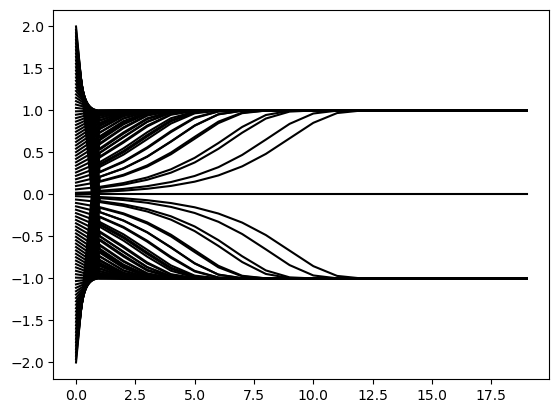

In [25]:
N = 20
x_start = np.linspace(-2,2,num=100)
x_start = np.append(x_start, 0) # Make sure that 0 is considered

def f(x):
    return x + 0.5*(x-x**3)

fig = plt.figure()
ax = fig.add_subplot(111)

for x0 in x_start:
    x_array = relaxation(f, N, x0)
    ax.plot(x_array, color='k')

There are 3 poles at +1, 0, and -1. These solutions will occur depending on the initial guess.

## Using inverse functions

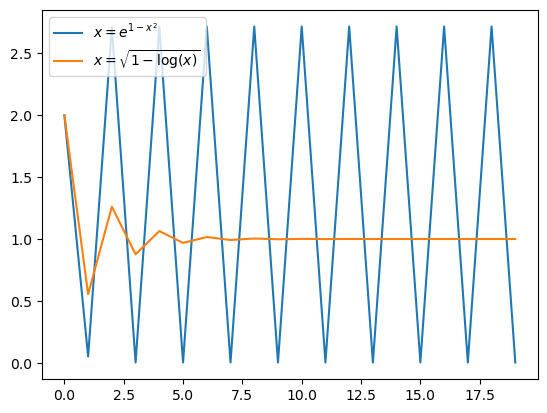

In [51]:
N = 20

def f(x):
    return np.exp(1-x**2)

def g(x):
    return np.sqrt(1-np.log(x))

x0 = 2

fx = relaxation(f, N, x0)
gx = relaxation(g, N, x0)

index_array = np.arange(N)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(index_array, fx, label=r"$x=e^{1-x^2}$")
ax.plot(index_array, gx, label=r"$x=\sqrt{1-\log(x)}$")
ax.legend(loc='upper left')

## Ferromagnetism

Equation for magnetism:

$$
m = \tanh\left(\frac{Cm}{T} \right)
$$

The error at each iteration:

$$
\delta' = \frac{m'-m}{T\cosh^2(m/T)-1}
$$

Text(0, 0.5, 'Magnetization')

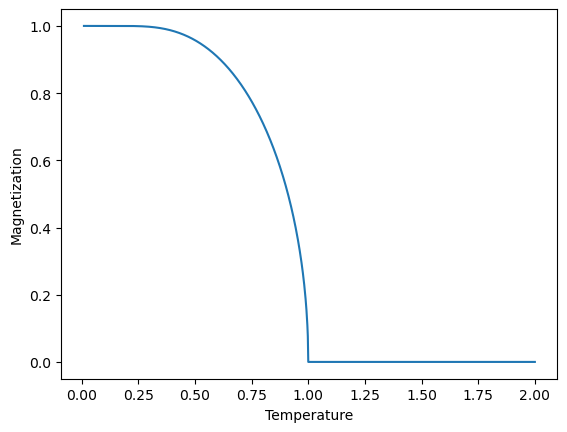

In [67]:
import numpy as np 
import matplotlib.pyplot as plt 

# Constants
T_max = 2.0
N = 1000
accuracy = 1e-6

# Arrays
m = np.zeros(N, dtype='float')
T = np.linspace(0.01, T_max, num=N)

def relaxation_mag(T, m, accuracy):
    for i, t in enumerate(T):
        error = 1.0
        m1 = 1.0
        while error > accuracy:
            m1, m2 = np.tanh(m1/t), m1
            error = np.abs((m2-m1)/(t*np.cosh(m2/t)**2-1))
        m[i] = m1
    return m 

relaxation_mag(T, m, accuracy)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(T, m)
ax.set_xlabel("Temperature")
ax.set_ylabel("Magnetization")

When the temperature is $T = k_B/\mu J$ ($k_B$ is the Boltzmann constant, $\mu$ is the magnetic moment, and $J$ is the coupling constant), the ferromagnetic material loses it magnetism.

## Binary search

Consider the same equation as the beginning of this notebook:

$$
e^{-x} + x - 2 = f(x) = 0
$$

First, we can plot $f(x)$ between $x=0$ and $x=3$.

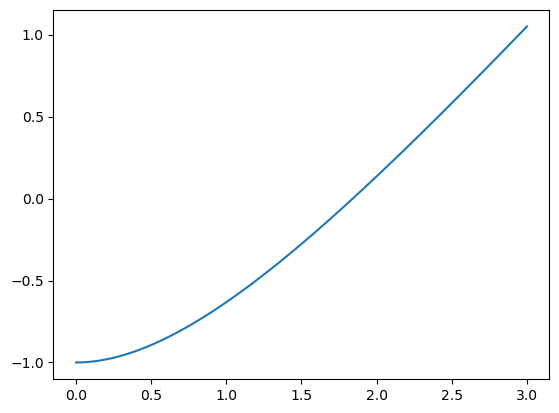

In [26]:
import numpy as np 
import matplotlib.pyplot as plt 

x = np.linspace(0,3,num=300)

def f(x):
    return np.exp(-x) + x - 2

y = f(x)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(x, y)

The function has one crossing where $f(x)=0$. The value of $x$ at that point is our solution. 

We can look for the value of the root.

In [28]:
def binary_search(f, x1, x2, accuracy):
    error  = np.abs(x2-x1)
    while error > accuracy:
        xp = (x1+x2)/2
        yp = f(xp)
        if yp >= 0:
            x2 = xp
        else:
            x1 = xp
        error = np.abs(x2-x1)
    return xp

x1 = 0.0
x2 = 3.0
accuracy = 1e-6

x = binary_search(f, x1, x2, accuracy)

print(f"The value of root is x = {x:.6f}. The relaxation method yielded 1.841406.")

The value of root is x = 1.841405. The relaxation method yielded 1.841406.


We can see that binary search provides a similar solution.